# Decision-Model Evaluation (Jev)

This notebook evaluates `DecisionTitleAbstractReviewer` with TypeSafe's **Jev** (a System One decision model) on the
same data as the v1 LLM evaluations:

- **Custom searches 1-3** (`custom_evaluation.ipynb`): 978 radiology AI articles screened against three sets of
  criteria of increasing difficulty.
- **Six SYNERGY datasets** (`synergy_evaluation.ipynb`): 8,859 articles from published systematic reviews.

Each CSV already stores the v1 LLM decisions (Agent1 `gemini-2.5-flash`, Agent2 `gpt-4o-mini`, and Agent3 `gpt-4o`
on disagreements), so Jev is compared against them at no extra cost. Criteria are passed exactly as the LLMs got
them: the numbered dicts for the custom searches and the original strings for SYNERGY (one criterion each).

Jev results are cached in `decision_results/`, so re-running this notebook does not call the API again.

## Setting up the notebook

In [1]:
from dotenv import load_dotenv

# Load environment variables from .env file. Adjust the path to the .env file as needed.
load_dotenv(dotenv_path="../.env")

# Enable asyncio in Jupyter
import asyncio
import nest_asyncio

nest_asyncio.apply()

# Add the package to the path (required if you are running this notebook from the evaluation folder)
import sys

sys.path.append("../")

In [2]:
import contextlib
import io
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lattereview.providers import SystemOneProvider
from lattereview.agents import DecisionTitleAbstractReviewer
from lattereview.workflows import ReviewWorkflow
from lattereview.utils import suggest_threshold

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Datasets and criteria

In [3]:
CUSTOM_CRITERIA = {
    "search1": {
        "inclusion_criteria": {
            1: "The study must involve CT scans. If multiple modalities are involved, CT scans should be among them.",
        },
        "exclusion_criteria": {
            1: "The study must not include PET scans as one of its modalities.",
        },
    },
    "search2": {
        "inclusion_criteria": {
            1: "The study must involve CT scans. If multiple modalities are involved, CT scans should be among them.",
            2: "The study should introduce, develop, or discuss a deep learning-baseed classifier.",
        },
        "exclusion_criteria": {
            1: "The study must not include PET scans as one of its modalities.",
            2: "Studies focusing on cardiovascular organs or lung vasculature must be excluded.",
        },
    },
    "search3": {
        "inclusion_criteria": {
            1: "The study must involve CT scans. If multiple modalities are involved, CT scans should be among them.",
            2: "The study should introduce, develop, or discuss a deep learning-baseed classifier.",
            3: "The clinical application or model in the study must focus on diagnosis.",
        },
        "exclusion_criteria": {
            1: "The study must not include PET scans as one of its modalities.",
            2: "Studies focusing on cardiovascular organs or lung vasculature must be excluded.",
            3: "All studies that did not have an external test set in addition to their internal test set must be excluded.",
        },
    },
}

In [4]:
SYNERGY_CRITERIA = {'Appenzeller-Herzog_2019': {'inclusion_criteria': "-Patients with Wilson's Disease of any age or stage\n"
                                                   '-Study drug has to be one of four established therapies, '
                                                   'namely DPen, trientine, TTM or Zn.\n'
                                                   '-Control could be placebo, no treatment or any other '
                                                   'treatment that does not include the respective study '
                                                   'drug\n'
                                                   '-Concomitant therapies had to be identical in the '
                                                   'compared treatment arms\n'
                                                   '-Combination therapy regimens that include the '
                                                   'respective monotherapy drug are not considered\n'
                                                   '-Prospective or retrospective studies reported\n'
                                                   '-Randomized, non-randomized controlled trials and '
                                                   'comparative observational studies',
                             'exclusion_criteria': '-Animal studies, case reports, case series, '
                                                   'cross-sectional studies, before-after studies, reviews, '
                                                   'letters, abstract-only publications, editorials, '
                                                   'diagnostic or other testing studies and non-controlled '
                                                   'studies'},
 'Donners_2021': {'inclusion_criteria': 'The following inclusion criteria are applied: emicizumab studies '
                                        'providing (1) data on humans, (2) original PK data or modeled PK '
                                        'data or PK/PD relationships, and (3) access to the abstract and the '
                                        'full text in English. In the event of doubt regarding eligibility, '
                                        'the records or articles should be included.',
                  'exclusion_criteria': 'Not specified'},
 'Jeyaraman_2020': {'inclusion_criteria': 'Studies are included if they meet the following PICOS criteria: '
                                          'Population: Patients with knee osteoarthritis Intervention: MSC '
                                          'therapy Comparator: Usual care Outcomes: Visual Analog Score '
                                          '(VAS) for Pain, Western Ontario McMaster Universities '
                                          'Osteoarthritis Index (WOMAC), Lysholm Knee Scale (Lysholm), '
                                          'Whole-Organ Magnetic Resonance Imaging Score (WORMS), Knee '
                                          'Osteoarthritis Outcome Score (KOOS), and adverse events Study '
                                          'Design: Randomized controlled trials',
                    'exclusion_criteria': 'Trials are excluded if they had the following characteristics: 1. '
                                          'Observational studies and interventional studies without a '
                                          'comparator group 2. Animal studies involving stem cell therapy '
                                          'for knee osteoarthritis models 3. Review'},
 'Meijboom_2021': {'inclusion_criteria': 'Articles are included if they meet the following criteria: (1) '
                                         'study involved transitioning from a TNF-alpha inhibitor (including '
                                         'etanercept, infliximab, and adalimumab) originator to a '
                                         'biosimilar, (2) the number of patients who retransitioned is '
                                         'reported or can be calculated, (3) the article is an original '
                                         'research article published in a peer-reviewed journal, (4) the '
                                         'article included baseline characteristics of the patients who '
                                         'transitioned, (5) the article is written in English. Transitioning '
                                         'is defined as patients in whom the biosimilar was introduced after '
                                         'the originator, without treatment with other drugs in between. '
                                         'Retransitioning is defined as restarting the originator directly '
                                         'after discontinuing a biosimilar, without treatment with other '
                                         'drugs in between. In summary, transitioning is defined as '
                                         'switching from the originator to a biosimilar; retransitioning is '
                                         'defined as switching from the originator to a biosimilar and back '
                                         'to the originator. Both transitioning and retransitioning involve '
                                         'changes with the same active biological substance.',
                   'exclusion_criteria': 'Not specified'},
 'Muthu_2021': {'inclusion_criteria': 'To be included, a study should meet the following criteria: 1. The '
                                      'study should be an RCT with 1:1 parallel two-arm design. 2. The study '
                                      'must be related to spine surgery involving preoperative or '
                                      'intraoperative or postoperative variables. 3. The study must have a '
                                      'dichotomous primary or secondary outcome.',
                'exclusion_criteria': '1. Studies not involving human subjects. 2. Studies with continuous '
                                      'variable outcomes like pain scores, Oswestry Disability Index scores, '
                                      'time to union without predefined clinical success criteria. 3. '
                                      'Studies that did not report a statistically significant primary or '
                                      'secondary outcome measure.'},
 'Oud_2018': {'inclusion_criteria': 'Randomized controlled trials (RCT)s on four specialized psychotherapies '
                                    '(DBT: dialectic behavior therapy, MBT: mentalization-based treatment, '
                                    'TFP: transference-focused therapy and ST: schema therapy) for adults '
                                    '(18 years and older) with Borderline personality disorder (BPD), which '
                                    'includes an individual psychotherapy component and had a duration of 16 '
                                    'weeks or more. Eligible comparison groups are other protocolized and '
                                    'specialized psychotherapies, or control groups, for example, treatment '
                                    'as usual (TAU), waiting list, attention control or community treatment '
                                    'by experts (CTBE).',
              'exclusion_criteria': 'Studies are excluded with a cut-off of <66% of the participants having '
                                    'BPD, unless disaggregated data are provided. Studies are excluded that '
                                    'tested incomplete versions of specialized treatment, for example, '
                                    'studies that investigated only skills training instead of the full DBT '
                                    'program.'}}

In [5]:
# The larger SYNERGY sets run on OpenRouter (same Jev model, separate billing); the rest on TypeSafe directly.
BACKENDS = {"Appenzeller-Herzog_2019": "openrouter", "Muthu_2021": "openrouter"}
DATASETS = ["search1", "search2", "search3"] + sorted(SYNERGY_CRITERIA)
RESULTS_DIR = "decision_results"
SAMPLE_SIZE = None  # set to an int to try the notebook on a small sample (results go to a separate folder)


def llm_score(row):
    """The stored v1 LLM decision, computed as in synergy_evaluation.ipynb: Agent3 if it reviewed, else the mean."""
    if "round-B_Agent3_output" in row and not pd.isna(row["round-B_Agent3_evaluation"]):
        return int(row["round-B_Agent3_evaluation"])
    return (int(row["round-A_Agent1_evaluation"]) + int(row["round-A_Agent2_evaluation"])) / 2


def load_dataset(name):
    """Return (data, inclusion_criteria, exclusion_criteria) with `label` and `llm_score` columns."""
    if name in CUSTOM_CRITERIA:
        df = pd.read_csv(f"custom_data/{name}_reviewed.csv", index_col=0)
        df["label"] = df[name].astype(int)
        criteria = CUSTOM_CRITERIA[name]
    else:
        df = pd.read_csv(f"synergy_data/{name}_reviewed.csv", index_col=0)
        df["label"] = df["label_included"].astype(int)
        criteria = SYNERGY_CRITERIA[name]
    df["llm_score"] = df.apply(llm_score, axis=1)
    exclusion = criteria["exclusion_criteria"]
    if isinstance(exclusion, str) and exclusion.strip().lower() == "not specified":
        exclusion = ""
    return df, criteria["inclusion_criteria"], exclusion


for name in DATASETS:
    df, _, _ = load_dataset(name)
    print(f"{name:25s} {len(df):5d} articles, {df['label'].sum():4d} included ({df['label'].mean():.1%})")

search1                     978 articles,  697 included (71.3%)
search2                     978 articles,  367 included (37.5%)
search3                     978 articles,   55 included (5.6%)
Appenzeller-Herzog_2019    2873 articles,   26 included (0.9%)
Donners_2021                258 articles,   15 included (5.8%)
Jeyaraman_2020             1175 articles,   96 included (8.2%)
Meijboom_2021               882 articles,   37 included (4.2%)
Muthu_2021                 2719 articles,  336 included (12.4%)
Oud_2018                    952 articles,   20 included (2.1%)


## Running Jev

One `DecisionTitleAbstractReviewer` per dataset. Each article is one request carrying all questions: the 5-level
evaluation score, the overall include question, and one question per criterion. Only a compact result table is saved.

In [6]:
async def run_jev(name):
    df, inclusion, exclusion = load_dataset(name)
    if SAMPLE_SIZE:  # stratified: a quarter included articles
        included, excluded = df[df["label"] == 1], df[df["label"] == 0]
        n_included = min(SAMPLE_SIZE // 4, len(included))
        df = pd.concat([included.sample(n_included, random_state=0), excluded.sample(SAMPLE_SIZE - n_included, random_state=0)])
    provider = SystemOneProvider(backend=BACKENDS.get(name, "typesafe"))
    reviewer = DecisionTitleAbstractReviewer(
        provider=provider,
        name="Jev",
        inclusion_criteria=inclusion,
        exclusion_criteria=exclusion,
        verbose=False,
    )
    workflow = ReviewWorkflow(
        workflow_schema=[{"round": "A", "reviewers": [reviewer], "text_inputs": ["title", "abstract"]}],
        verbose=False,
    )
    start = time.time()
    reviewed = await workflow(df)
    seconds = time.time() - start
    await provider.aclose()

    results = pd.DataFrame(
        {
            "label": reviewed["label"],
            "llm_score": reviewed["llm_score"],
            "jev_evaluation": reviewed["round-A_Jev_evaluation"],
            "jev_include_probability": reviewed["round-A_Jev_include_probability"],
            "jev_confidence": reviewed["round-A_Jev_confidence"],
            "jev_answers": reviewed["round-A_Jev_output"].apply(lambda output: json.dumps(output["_answers"])),
        }
    )
    run = {"backend": provider.backend, "model": provider.model, "items": len(df), "seconds": seconds}
    run["cost"] = workflow.get_total_cost()
    return results, run


results_dir = RESULTS_DIR if not SAMPLE_SIZE else f"{RESULTS_DIR}_sample"
os.makedirs(results_dir, exist_ok=True)
runs_path = f"{results_dir}/runs.json"
runs = json.load(open(runs_path)) if os.path.exists(runs_path) else {}

for name in DATASETS:
    path = f"{results_dir}/{name}.csv"
    if os.path.exists(path):
        print(f"{name}: cached")
        continue
    with contextlib.redirect_stderr(io.StringIO()):  # hide the per-item progress bars
        results, run = asyncio.run(run_jev(name))
    results.to_csv(path)
    runs[name] = run
    json.dump(runs, open(runs_path, "w"), indent=1)
    print(f"{name}: {run['items']} items in {run['seconds']:.0f}s on {run['backend']}, ${run['cost']:.4f}")

search1: 978 items in 78s on typesafe, $0.0467


search2: 978 items in 107s on typesafe, $0.0552


search3: 978 items in 95s on typesafe, $0.0641


Appenzeller-Herzog_2019: 2873 items in 194s on openrouter, $0.1573


Donners_2021: 258 items in 16s on typesafe, $0.0142


Jeyaraman_2020: 1175 items in 71s on typesafe, $0.0764


Meijboom_2021: 882 items in 53s on typesafe, $0.0617


Muthu_2021: 2719 items in 166s on openrouter, $0.1697


Oud_2018: 952 items in 57s on typesafe, $0.0610


In [7]:
runs_table = pd.DataFrame(runs).T[["backend", "model", "items", "seconds", "cost"]]
runs_table["items_per_second"] = runs_table["items"] / runs_table["seconds"].astype(float)
runs_table["cost_per_1k_items"] = runs_table["cost"].astype(float) / runs_table["items"].astype(float) * 1000
print(f"Total: {runs_table['items'].sum()} items, {runs_table['seconds'].sum() / 60:.1f} min, ${runs_table['cost'].sum():.3f}")
runs_table.round(4)

Total: 11793 items, 14.0 min, $0.706


,backend,model,items,seconds,cost,items_per_second,cost_per_1k_items
search1,typesafe,jev-latest,978,78.341723,0.046725,12.483769,0.0478
search2,typesafe,jev-latest,978,106.617475,0.055228,9.17298,0.0565
search3,typesafe,jev-latest,978,95.096855,0.064101,10.284252,0.0655
Appenzeller-Herzog_2019,openrouter,~typesafe/jev-latest,2873,194.442451,0.157322,14.77558,0.0548
Donners_2021,typesafe,jev-latest,258,15.643841,0.014226,16.492113,0.0551
Jeyaraman_2020,typesafe,jev-latest,1175,70.77586,0.076374,16.601706,0.0650
Meijboom_2021,typesafe,jev-latest,882,53.096449,0.061708,16.61128,0.0700
Muthu_2021,openrouter,~typesafe/jev-latest,2719,166.423473,0.169664,16.33784,0.0624
Oud_2018,typesafe,jev-latest,952,57.363047,0.061011,16.59605,0.0641


## Screening signals

`DecisionTitleAbstractReviewer` produces several numbers per article. We compare how well each one ranks the
included articles above the excluded ones:

- `include_probability`: Jev's probability for "meets ALL inclusion and NONE of the exclusion criteria".
- `expected_evaluation`: the expected value (1-5) of the 5-level evaluation score.
- `criteria_product`: the product of the per-criterion probabilities, prod p(inclusion met) x prod (1 - p(exclusion applies)).
- `evaluation`: the most likely evaluation level (1-5), the column that mirrors `TitleAbstractReviewer`.
- `llm_score`: the stored v1 LLM decision (1-5, averaged over two reviewers or the senior reviewer's score).

Metrics: **AUC**, and **WSS@95**, the work saved over sampling at 95% recall (the fraction of articles a reviewer
would not need to read at the cutoff that still finds 95% of the included ones, minus the 5% recall given up).

In [8]:
def add_signals(df):
    answers = df["jev_answers"].apply(json.loads)
    df["expected_evaluation"] = answers.apply(lambda a: a["evaluation"]["value"] + 1)
    df["criteria_product"] = answers.apply(
        lambda a: np.prod([v["value"] if k.startswith("inc_") else 1 - v["value"] for k, v in a.items() if k[:4] in ("inc_", "exc_")])
    )
    df["include_probability"] = df["jev_include_probability"]
    df["evaluation"] = df["jev_evaluation"]
    return df


def auc(labels, scores):
    """Area under the ROC curve via the rank-sum (Mann-Whitney) formula; ties count half."""
    ranks = pd.Series(scores).rank().to_numpy()
    labels = np.asarray(labels).astype(bool)
    n_pos, n_neg = labels.sum(), (~labels).sum()
    return (ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def recall_precision(labels, predicted):
    labels, predicted = np.asarray(labels).astype(bool), np.asarray(predicted).astype(bool)
    tp = (labels & predicted).sum()
    return tp / labels.sum(), (tp / predicted.sum() if predicted.sum() else float("nan")), predicted.mean()


data = {name: add_signals(pd.read_csv(f"{results_dir}/{name}.csv", index_col=0)) for name in DATASETS}
SIGNALS = ["include_probability", "expected_evaluation", "criteria_product", "evaluation", "llm_score"]

rows = []
for name, df in data.items():
    for signal in SIGNALS:
        rows.append(
            {
                "dataset": name,
                "signal": signal,
                "auc": auc(df["label"], df[signal]),
                "wss@95": suggest_threshold(df, signal, "label", target_recall=0.95)["wss"],
            }
        )
signal_table = pd.DataFrame(rows)
auc_table = signal_table.pivot(index="dataset", columns="signal", values="auc").loc[DATASETS, SIGNALS]
wss_table = signal_table.pivot(index="dataset", columns="signal", values="wss@95").loc[DATASETS, SIGNALS]
auc_table.loc["mean"] = auc_table.mean()
wss_table.loc["mean"] = wss_table.mean()
print("AUC")
display(auc_table.round(3))
print("WSS@95")
display(wss_table.round(3))

AUC


signal,include_probability,expected_evaluation,criteria_product,evaluation,llm_score
dataset,,,,,
search1,0.957,0.968,0.957,0.942,0.937
search2,0.875,0.882,0.882,0.824,0.818
search3,0.865,0.867,0.863,0.838,0.789
Appenzeller-Herzog_2019,0.899,0.882,0.878,0.655,0.847
Donners_2021,0.923,0.919,0.927,0.833,0.772
Jeyaraman_2020,0.795,0.843,0.926,0.555,0.708
Meijboom_2021,0.941,0.932,0.928,0.902,0.902
Muthu_2021,0.735,0.736,0.711,0.601,0.728
Oud_2018,0.969,0.969,0.972,0.923,0.955


WSS@95


signal,include_probability,expected_evaluation,criteria_product,evaluation,llm_score
dataset,,,,,
search1,0.249,0.252,0.244,0.253,0.000
search2,0.225,0.271,0.258,0.000,0.251
search3,0.323,0.217,0.415,0.000,0.081
Appenzeller-Herzog_2019,0.644,0.677,0.597,0.000,0.000
Donners_2021,0.659,0.647,0.682,0.000,0.070
Jeyaraman_2020,0.000,0.000,0.500,0.000,0.000
Meijboom_2021,0.756,0.771,0.724,0.000,0.538
Muthu_2021,0.169,0.272,0.160,0.000,0.272
Oud_2018,0.867,0.863,0.867,0.000,0.798


## Recall and precision at fixed cutoffs

Without labeled data to fit a cutoff, a user would include articles with `include_probability >= 0.5` or
`evaluation >= 3` / `>= 4`, as with the LLM reviewers. The LLM rows use the stored v1 decisions.

In [9]:
CUTOFFS = {
    "Jev include_probability >= 0.5": lambda df: df["include_probability"] >= 0.5,
    "Jev evaluation >= 3": lambda df: df["evaluation"] >= 3,
    "Jev evaluation >= 4": lambda df: df["evaluation"] >= 4,
    "LLM score >= 3": lambda df: df["llm_score"] >= 3,
    "LLM score >= 4": lambda df: df["llm_score"] >= 4,
}
rows = []
for name, df in data.items():
    for label, rule in CUTOFFS.items():
        recall, precision, fraction = recall_precision(df["label"], rule(df))
        rows.append({"dataset": name, "rule": label, "recall": recall, "precision": precision, "included": fraction})
cutoff_table = pd.DataFrame(rows)
for metric in ["recall", "precision"]:
    print(metric)
    display(cutoff_table.pivot(index="dataset", columns="rule", values=metric).loc[DATASETS, list(CUTOFFS)].round(3))

recall


rule,Jev include_probability >= 0.5,Jev evaluation >= 3,Jev evaluation >= 4,LLM score >= 3,LLM score >= 4
dataset,,,,,
search1,0.920,0.954,0.914,0.920,0.904
search2,0.853,0.866,0.856,0.837,0.828
search3,0.564,0.655,0.600,0.782,0.782
Appenzeller-Herzog_2019,0.077,0.231,0.231,0.308,0.231
Donners_2021,0.667,0.733,0.667,0.733,0.733
Jeyaraman_2020,0.000,0.000,0.000,0.021,0.021
Meijboom_2021,0.135,0.324,0.270,0.838,0.838
Muthu_2021,0.077,0.226,0.205,0.235,0.190
Oud_2018,0.700,0.850,0.750,0.800,0.500


precision


rule,Jev include_probability >= 0.5,Jev evaluation >= 3,Jev evaluation >= 4,LLM score >= 3,LLM score >= 4
dataset,,,,,
search1,0.970,0.969,0.970,0.970,0.971
search2,0.688,0.677,0.684,0.663,0.667
search3,0.348,0.281,0.359,0.128,0.132
Appenzeller-Herzog_2019,0.286,0.050,0.400,0.075,0.118
Donners_2021,0.435,0.275,0.278,0.124,0.129
Jeyaraman_2020,NaN,NaN,NaN,0.667,0.667
Meijboom_2021,0.833,0.273,0.476,0.244,0.254
Muthu_2021,0.271,0.278,0.277,0.277,0.270
Oud_2018,0.292,0.254,0.294,0.208,0.270


## Cutoffs fitted for 95% recall

`suggest_threshold` finds the highest `include_probability` cutoff that still reaches 95% recall. The fitted cutoff
differs a lot between datasets, which is why it should be fitted on a labeled sample of your own data.

In [10]:
rows = []
for name, df in data.items():
    fitted = suggest_threshold(df, "include_probability", "label", target_recall=0.95)
    rows.append({"dataset": name, **fitted})
display(pd.DataFrame(rows).set_index("dataset").round(3))

,threshold,recall,precision,n_included,wss
dataset,,,,,
search1,0.23,0.953,0.965,688,0.249
search2,0.05,0.962,0.490,721,0.225
search3,0.04,0.964,0.085,627,0.323
Appenzeller-Herzog_2019,0.03,0.962,0.027,913,0.644
Donners_2021,0.11,1.000,0.170,88,0.659
Jeyaraman_2020,0.01,1.000,0.082,1175,0.000
Meijboom_2021,0.10,0.973,0.188,191,0.756
Muthu_2021,0.02,0.985,0.149,2220,0.169
Oud_2018,0.20,0.950,0.241,79,0.867


## Hybrid: Jev first, LLM only for uncertain articles

Jev screens every article. Articles with `include_probability` inside an uncertain band go to the LLM (here, the
stored v1 LLM decision with `llm_score >= 3`); the rest keep Jev's decision (`include_probability >= 0.5`).
The LLM cost is estimated at $0.0001 per article, the measured cost of `TitleAbstractReviewer` with `gpt-6-luna`.

In [11]:
LLM_COST_PER_ITEM = 0.0001
BANDS = [(0.1, 0.9), (0.05, 0.95), (0.02, 0.98)]

rows = []
for name, df in data.items():
    jev_cost_per_item = runs[name]["cost"] / runs[name]["items"]
    llm_recall, llm_precision, _ = recall_precision(df["label"], df["llm_score"] >= 3)
    jev_recall, jev_precision, _ = recall_precision(df["label"], df["include_probability"] >= 0.5)
    rows.append({"dataset": name, "pipeline": "LLM only (>= 3)", "routed_to_llm": 1.0, "recall": llm_recall, "precision": llm_precision, "cost_per_1k": 1000 * LLM_COST_PER_ITEM})
    rows.append({"dataset": name, "pipeline": "Jev only (p >= 0.5)", "routed_to_llm": 0.0, "recall": jev_recall, "precision": jev_precision, "cost_per_1k": 1000 * jev_cost_per_item})
    for low, high in BANDS:
        uncertain = (df["include_probability"] >= low) & (df["include_probability"] < high)
        decision = np.where(uncertain, df["llm_score"] >= 3, df["include_probability"] >= 0.5)
        recall, precision, _ = recall_precision(df["label"], decision)
        cost = 1000 * (jev_cost_per_item + uncertain.mean() * LLM_COST_PER_ITEM)
        rows.append({"dataset": name, "pipeline": f"Hybrid band [{low}, {high})", "routed_to_llm": uncertain.mean(), "recall": recall, "precision": precision, "cost_per_1k": cost})
hybrid_table = pd.DataFrame(rows)
pipelines = list(dict.fromkeys(hybrid_table["pipeline"]))
for metric in ["routed_to_llm", "recall", "precision"]:
    print(metric)
    display(hybrid_table.pivot(index="dataset", columns="pipeline", values=metric).loc[DATASETS, pipelines].round(3))
display(hybrid_table.groupby("pipeline", sort=False)[["routed_to_llm", "recall", "precision", "cost_per_1k"]].mean().round(4))

routed_to_llm


pipeline,LLM only (>= 3),Jev only (p >= 0.5),"Hybrid band [0.1, 0.9)","Hybrid band [0.05, 0.95)","Hybrid band [0.02, 0.98)"
dataset,,,,,
search1,1.0,0.0,0.074,0.124,0.988
search2,1.0,0.0,0.210,0.479,0.990
search3,1.0,0.0,0.434,0.549,0.982
Appenzeller-Herzog_2019,1.0,0.0,0.047,0.122,0.747
Donners_2021,1.0,0.0,0.360,0.698,1.000
Jeyaraman_2020,1.0,0.0,0.005,0.017,0.308
Meijboom_2021,1.0,0.0,0.217,0.314,0.740
Muthu_2021,1.0,0.0,0.292,0.472,0.816
Oud_2018,1.0,0.0,0.114,0.164,0.436


recall


pipeline,LLM only (>= 3),Jev only (p >= 0.5),"Hybrid band [0.1, 0.9)","Hybrid band [0.05, 0.95)","Hybrid band [0.02, 0.98)"
dataset,,,,,
search1,0.920,0.920,0.920,0.920,0.920
search2,0.837,0.853,0.837,0.837,0.837
search3,0.782,0.564,0.782,0.782,0.782
Appenzeller-Herzog_2019,0.308,0.077,0.231,0.231,0.308
Donners_2021,0.733,0.667,0.733,0.733,0.733
Jeyaraman_2020,0.021,0.000,0.010,0.021,0.021
Meijboom_2021,0.838,0.135,0.811,0.838,0.838
Muthu_2021,0.235,0.077,0.214,0.232,0.235
Oud_2018,0.800,0.700,0.800,0.800,0.800


precision


pipeline,LLM only (>= 3),Jev only (p >= 0.5),"Hybrid band [0.1, 0.9)","Hybrid band [0.05, 0.95)","Hybrid band [0.02, 0.98)"
dataset,,,,,
search1,0.970,0.970,0.970,0.970,0.970
search2,0.663,0.688,0.666,0.663,0.663
search3,0.128,0.348,0.133,0.129,0.128
Appenzeller-Herzog_2019,0.075,0.286,0.143,0.087,0.075
Donners_2021,0.124,0.435,0.157,0.128,0.124
Jeyaraman_2020,0.667,NaN,0.500,0.667,0.667
Meijboom_2021,0.244,0.833,0.252,0.244,0.244
Muthu_2021,0.277,0.271,0.281,0.277,0.277
Oud_2018,0.208,0.292,0.232,0.216,0.208


,routed_to_llm,recall,precision,cost_per_1k
pipeline,,,,
LLM only (>= 3),1.0000,0.6081,0.3728,0.1000
Jev only (p >= 0.5),0.0000,0.4436,0.5153,0.0601
"Hybrid band [0.1, 0.9)",0.1947,0.5931,0.3704,0.0796
"Hybrid band [0.05, 0.95)",0.3264,0.5992,0.3756,0.0928
"Hybrid band [0.02, 0.98)",0.7786,0.6081,0.3728,0.1380


## Probability distribution

Jev's probabilities are close to 0 or 1 for most articles, so a narrow uncertain band routes few articles.

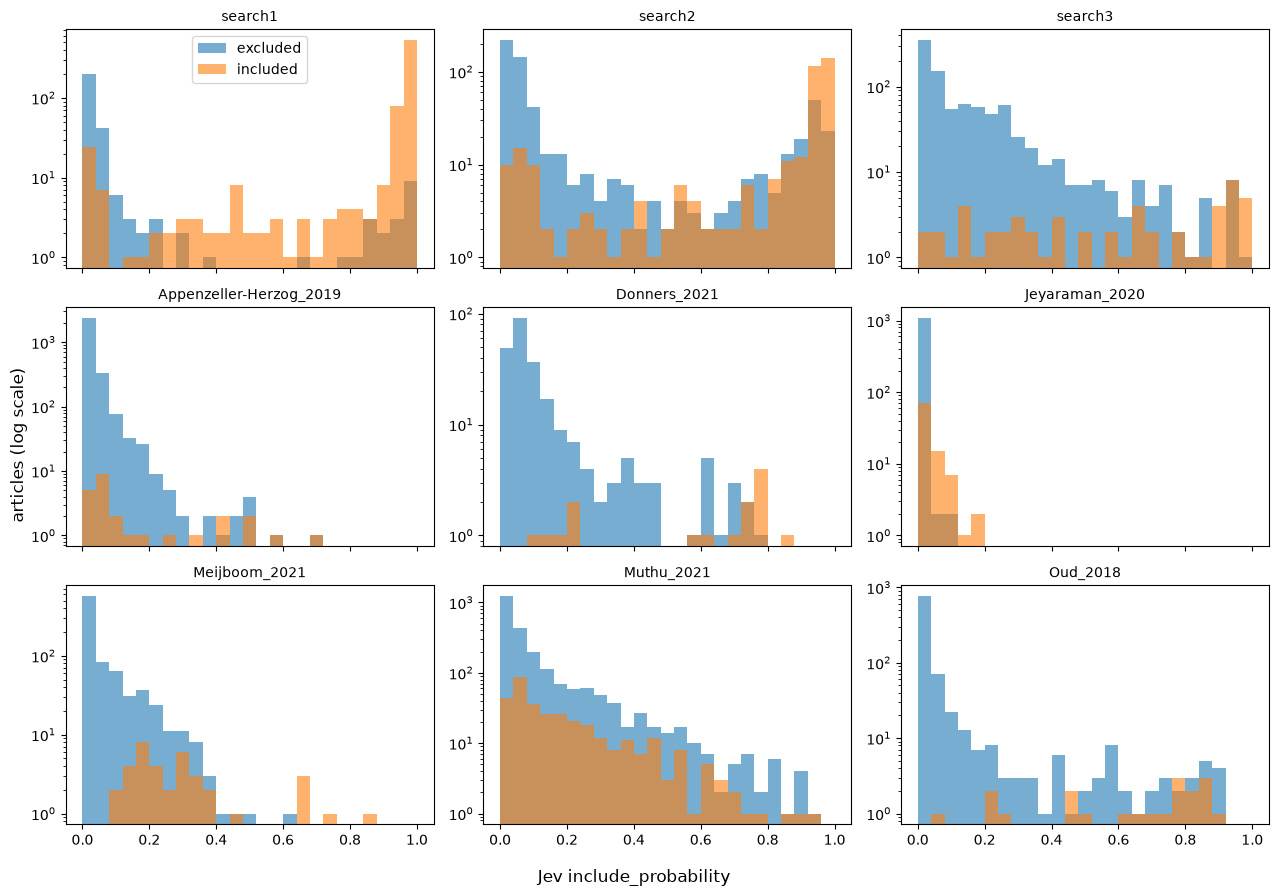

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
for ax, (name, df) in zip(axes.flat, data.items()):
    bins = np.linspace(0, 1, 26)
    ax.hist(df.loc[df["label"] == 0, "include_probability"], bins=bins, alpha=0.6, label="excluded", log=True)
    ax.hist(df.loc[df["label"] == 1, "include_probability"], bins=bins, alpha=0.6, label="included", log=True)
    ax.set_title(name, fontsize=10)
axes[0, 0].legend()
fig.supxlabel("Jev include_probability")
fig.supylabel("articles (log scale)")
plt.tight_layout()
plt.show()

## Summary

In [13]:
summary = pd.DataFrame(
    {
        "articles": [len(df) for df in data.values()],
        "included": [int(df["label"].sum()) for df in data.values()],
        "Jev AUC": auc_table.drop("mean")["include_probability"].values,
        "LLM AUC": auc_table.drop("mean")["llm_score"].values,
        "Jev WSS@95": wss_table.drop("mean")["include_probability"].values,
        "LLM WSS@95": wss_table.drop("mean")["llm_score"].values,
    },
    index=list(data),
)
summary.loc["mean"] = summary.mean()
summary.round(3)

,articles,included,Jev AUC,LLM AUC,Jev WSS@95,LLM WSS@95
search1,978.000,697.000,0.957,0.937,0.249,0.000
search2,978.000,367.000,0.875,0.818,0.225,0.251
search3,978.000,55.000,0.865,0.789,0.323,0.081
Appenzeller-Herzog_2019,2873.000,26.000,0.899,0.847,0.644,0.000
Donners_2021,258.000,15.000,0.923,0.772,0.659,0.070
Jeyaraman_2020,1175.000,96.000,0.795,0.708,0.000,0.000
Meijboom_2021,882.000,37.000,0.941,0.902,0.756,0.538
Muthu_2021,2719.000,336.000,0.735,0.728,0.169,0.272
Oud_2018,952.000,20.000,0.969,0.955,0.867,0.798
mean,1310.333,183.222,0.884,0.828,0.432,0.223
